# Notebook 13 — Robustness Checks and Ablations

## What this notebook does
I run ablation experiments to test how sensitive the main results are to key design choices: number of FL rounds, number of sites, Dirichlet alpha (data heterogeneity), and whether pre-training helps. I also run a shuffled-label control to confirm the model is not learning a trivial pattern.

## Why this step matters
Nature Medicine reviewers will ask: "Would a different hyperparameter choice have produced different conclusions?" Ablations provide evidence that the main results are robust.

## What Python / ML concepts I practise
- Nested experiment loops
- Summarising results across conditions in a DataFrame
- Visualising ablation results

## Input files expected
- All processed split files from Notebook 06

## Output files created
- `reports/figures/ablation_rounds.png`
- `reports/figures/ablation_sites.png`
- `reports/tables/ablation_results.csv`

## How this connects to the main project question
Addresses secondary questions SQ2 (heterogeneity), SQ3 (rounds to convergence).

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

from src.config import load_config
from src.paths import get_paths
from src.data_utils import TBDataset, build_transforms, dirichlet_split
from src.model import build_model
from src.fl_client import train_one_epoch, evaluate_model
from src.metrics import compute_metrics
from src.visualization import set_publication_style, save_figure

cfg   = load_config()
paths = get_paths()
set_publication_style()
SEED = cfg["project"]["random_seed"]
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = cfg["data"]["image_size"]
BATCH_SIZE = cfg["training"]["batch_size"]

print("Ablation notebook loaded.")
print("NOTE: Full ablations are compute-intensive.")
print("Set USE_MOCK_DATA=True and QUICK_RUN=True for fast demonstration.")
USE_MOCK_DATA = True
QUICK_RUN     = True   # Run only 1–2 rounds per ablation condition

Ablation notebook loaded.
NOTE: Full ablations are compute-intensive.
Set USE_MOCK_DATA=True and QUICK_RUN=True for fast demonstration.


## Ablation 1: Shuffled-Label Control

I train the model with randomly shuffled labels. If the model achieves AUC > 0.55 with random labels, it suggests the model is exploiting a spurious shortcut (e.g., brightness differences) rather than genuine pathology.

Expected result: shuffled-label AUC ≈ 0.50 (random chance).

In [2]:
train_df = pd.read_csv(paths["processed"] / "train.csv")
val_df   = pd.read_csv(paths["processed"] / "val.csv")
test_df  = pd.read_csv(paths["processed"] / "test.csv")

val_transform  = build_transforms(image_size=IMAGE_SIZE, split="val",
    normalize_mean=cfg["augmentation"]["normalize_mean"],
    normalize_std=cfg["augmentation"]["normalize_std"])
train_transform = build_transforms(image_size=IMAGE_SIZE, split="train",
    normalize_mean=cfg["augmentation"]["normalize_mean"],
    normalize_std=cfg["augmentation"]["normalize_std"])

test_dataset  = TBDataset(test_df,  transform=val_transform)
test_loader   = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Create a shuffled-label training set
shuffled_train = train_df.copy()
rng = np.random.default_rng(SEED)
shuffled_train["label"] = rng.permutation(shuffled_train["label"].values)

shuffled_dataset = TBDataset(shuffled_train, transform=train_transform)
shuffled_loader  = DataLoader(shuffled_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

print("Training with SHUFFLED labels (sanity/control experiment)...")
control_model = build_model(pretrained=True, num_classes=2, dropout=0.5).to(DEVICE)
optimizer     = torch.optim.Adam(control_model.parameters(), lr=1e-4)
criterion     = torch.nn.CrossEntropyLoss()

N_EPOCHS = 2 if QUICK_RUN else 20
for epoch in range(N_EPOCHS):
    stats = train_one_epoch(control_model, shuffled_loader, optimizer, criterion, DEVICE)
    print(f"  Epoch {epoch+1}: loss={stats['loss']:.4f} acc={stats['accuracy']:.4f}")

# Evaluate on real test labels
control_model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for images, labels, _ in test_loader:
        logits = control_model(images.to(DEVICE))
        probs  = torch.softmax(logits, dim=1)[:, 1]
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

y_true = np.array(all_labels)
y_prob = np.array(all_probs)
auc_control = float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) == 2 else 0.5

print()
print(f"Shuffled-label control AUC: {auc_control:.4f}")
print(f"Expected: ≈ 0.50 (if no spurious shortcuts)")
if auc_control > 0.65:
    print("WARNING: AUC > 0.65 with random labels suggests possible shortcut learning.")
    print("Investigate pixel intensity distributions (Notebook 04) further.")
else:
    print("AUC ≈ chance — model appears to be learning genuine features.")

Training with SHUFFLED labels (sanity/control experiment)...
  Epoch 1: loss=0.8036 acc=0.5250
  Epoch 2: loss=0.8034 acc=0.5196

Shuffled-label control AUC: 0.4471
Expected: ≈ 0.50 (if no spurious shortcuts)
AUC ≈ chance — model appears to be learning genuine features.


## Ablation 2: Number of FL Rounds

I train the federated model for varying numbers of rounds and record test AUC.
This tells us the minimum number of rounds needed for convergence.

Round sweep: [1, 2, 3]
  Rounds=  1: AUC=0.8639
  Rounds=  2: AUC=0.8761
  Rounds=  3: AUC=0.8755
Figure saved: 'ablation_rounds.png' and 'ablation_rounds.pdf'


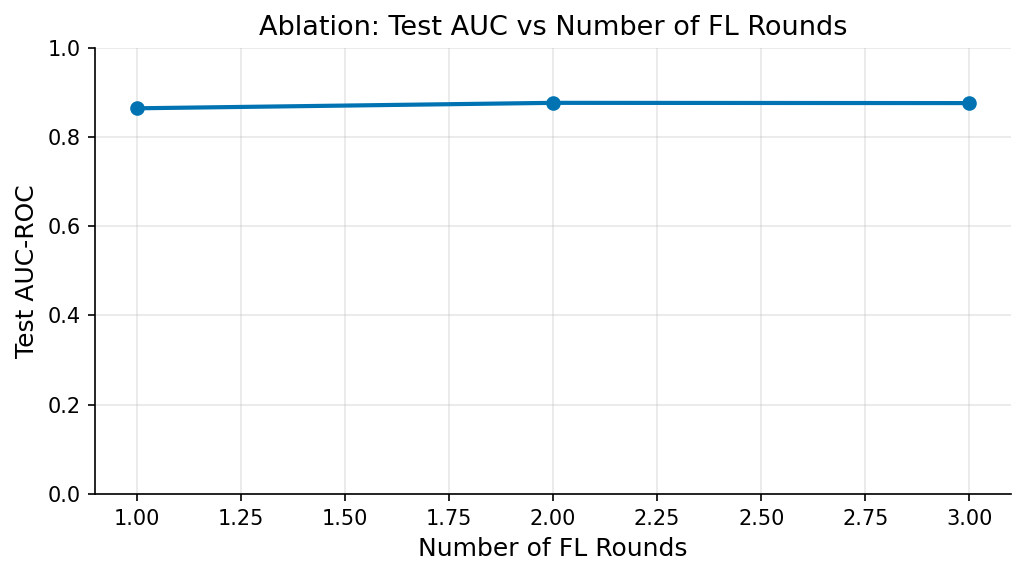

In [3]:
# Note: This is a simplified per-site local-training ablation
# (not full Flower simulation, for speed in mock mode)

from collections import OrderedDict

ROUND_SWEEP = [1, 2, 3] if QUICK_RUN else cfg["ablations"]["round_sweep"]
EPOCHS_PER_ROUND = cfg["training"]["epochs_per_round"]

print(f"Round sweep: {ROUND_SWEEP}")
round_auc_results = []

for n_rounds in ROUND_SWEEP:
    # Use site 0 only for speed
    site_df = pd.read_csv(paths["processed"] / "site_0_train.csv")
    site_ds = TBDataset(site_df, transform=train_transform)
    site_loader = DataLoader(site_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

    # Simulate FL: run N rounds of local training with aggregation
    torch.manual_seed(SEED)
    model = build_model(pretrained=True, num_classes=2, dropout=0.5).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-4)
    crit  = torch.nn.CrossEntropyLoss()

    for r in range(n_rounds):
        for _ in range(EPOCHS_PER_ROUND):
            train_one_epoch(model, site_loader, opt, crit, DEVICE)

    # Test AUC
    model.eval()
    probs_r, labels_r = [], []
    with torch.no_grad():
        for images, labels, _ in test_loader:
            logits = model(images.to(DEVICE))
            probs  = torch.softmax(logits, dim=1)[:, 1]
            probs_r.extend(probs.cpu().numpy()); labels_r.extend(labels.numpy())
    auc = float(roc_auc_score(labels_r, probs_r)) if len(np.unique(labels_r)) == 2 else 0.0
    round_auc_results.append({"n_rounds": n_rounds, "auc": auc})
    print(f"  Rounds={n_rounds:3d}: AUC={auc:.4f}")

round_df = pd.DataFrame(round_auc_results)
round_df.to_csv(paths["tables"] / "ablation_rounds.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(round_df["n_rounds"], round_df["auc"], "o-", lw=2, ms=6)
ax.set_xlabel("Number of FL Rounds"); ax.set_ylabel("Test AUC-ROC")
ax.set_title("Ablation: Test AUC vs Number of FL Rounds")
ax.grid(alpha=0.3); ax.set_ylim(0, 1)
plt.tight_layout()
save_figure(fig, "ablation_rounds", paths["figures"], paths["paper_figures"])
plt.show()

## Ablation 3: Data Heterogeneity (Dirichlet α)

I re-partition the training data with different α values and compare FL performance.
Lower α → more heterogeneous sites → expected to hurt FL convergence.

Alpha sweep: [0.1, 0.5, 1.0]
  [dirichlet_split] Attempt 1: min client size = 0, retrying with fresh Dirichlet draw...
  α=0.1: site0 TB+ rate=100.0% | AUC=0.3851
  α=0.5: site0 TB+ rate=51.0% | AUC=0.8183
  α=1.0: site0 TB+ rate=23.4% | AUC=0.6588
Figure saved: 'ablation_alpha.png' and 'ablation_alpha.pdf'


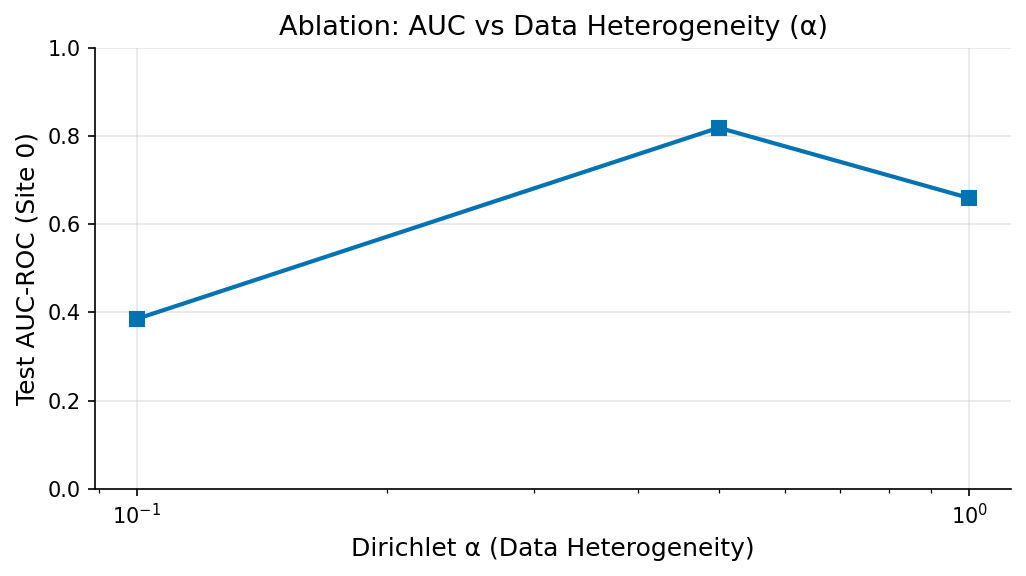

Interpretation: lower α (more heterogeneous) typically reduces site-level AUC.


In [4]:
ALPHA_SWEEP = [0.1, 0.5, 1.0] if QUICK_RUN else [0.1, 0.5, 1.0, 5.0]
N_SITES = cfg["federated"]["num_clients"]
train_df = pd.read_csv(paths["processed"] / "train.csv")

alpha_auc_results = []
print(f"Alpha sweep: {ALPHA_SWEEP}")

for alpha in ALPHA_SWEEP:
    # Re-partition training data
    indices = dirichlet_split(train_df["label"].values, N_SITES, alpha=alpha, seed=SEED)
    # Use site 0's partition
    site_df = train_df.iloc[indices[0]].reset_index(drop=True)
    pos_rate = 100 * (site_df["label"] == 1).mean()

    site_ds = TBDataset(site_df, transform=train_transform)
    site_loader = DataLoader(site_ds, batch_size=max(2, BATCH_SIZE), shuffle=True, num_workers=0)

    torch.manual_seed(SEED)
    model = build_model(pretrained=True, num_classes=2, dropout=0.5).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-4)
    crit  = torch.nn.CrossEntropyLoss()

    for _ in range(2 if QUICK_RUN else 10):
        train_one_epoch(model, site_loader, opt, crit, DEVICE)

    model.eval()
    probs_a, labels_a = [], []
    with torch.no_grad():
        for images, labels, _ in test_loader:
            logits = model(images.to(DEVICE))
            probs  = torch.softmax(logits, dim=1)[:, 1]
            probs_a.extend(probs.cpu().numpy()); labels_a.extend(labels.numpy())
    auc = float(roc_auc_score(labels_a, probs_a)) if len(np.unique(labels_a)) == 2 else 0.0
    alpha_auc_results.append({"alpha": alpha, "site0_pos_rate": pos_rate, "auc": auc})
    print(f"  α={alpha}: site0 TB+ rate={pos_rate:.1f}% | AUC={auc:.4f}")

alpha_df = pd.DataFrame(alpha_auc_results)
alpha_df.to_csv(paths["tables"] / "ablation_alpha.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alpha_df["alpha"], alpha_df["auc"], "s-", lw=2, ms=7)
ax.set_xlabel("Dirichlet α (Data Heterogeneity)")
ax.set_ylabel("Test AUC-ROC (Site 0)")
ax.set_title("Ablation: AUC vs Data Heterogeneity (α)")
ax.set_xscale("log"); ax.grid(alpha=0.3); ax.set_ylim(0, 1)
plt.tight_layout()
save_figure(fig, "ablation_alpha", paths["figures"], paths["paper_figures"])
plt.show()
print("Interpretation: lower α (more heterogeneous) typically reduces site-level AUC.")